# Model Training

This notebook holds a proof of concept of how the model would be trained using the gold table. The model is chosen between a binary classification logistic regression model and XGBoost model that outputs the **probability of a customer defaulting their loan**. Loaning decisions are made by setting a threshold probability based on **F2-score**, as we want to be conservative in giving out loans and prioritize low-risk individuals (i.e. minimize false negatives, which rates a high risk individual as low risk).

In [83]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, fbeta_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, fbeta_score

import pickle

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split


In [84]:
# Build a .py script that takes a snapshot date, trains a model and outputs artefact into storage.

## set up pyspark session

In [85]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

## set up config

In [86]:
# set up config
model_train_date_str = "2024-09-01"
train_test_period_months = 12
oot_period_months = 2
train_test_ratio = 0.8

config = {}
config["model_train_date_str"] = model_train_date_str
config["train_test_period_months"] = train_test_period_months
config["oot_period_months"] =  oot_period_months
config["model_train_date"] =  datetime.strptime(model_train_date_str, "%Y-%m-%d")
config["oot_end_date"] =  config['model_train_date'] - timedelta(days = 1)
config["oot_start_date"] =  config['model_train_date'] - relativedelta(months = oot_period_months)
config["train_test_end_date"] =  config["oot_start_date"] - timedelta(days = 1)
config["train_test_start_date"] =  config["oot_start_date"] - relativedelta(months = train_test_period_months)
config["train_test_ratio"] = train_test_ratio 


pprint.pprint(config)

{'model_train_date': datetime.datetime(2024, 9, 1, 0, 0),
 'model_train_date_str': '2024-09-01',
 'oot_end_date': datetime.datetime(2024, 8, 31, 0, 0),
 'oot_period_months': 2,
 'oot_start_date': datetime.datetime(2024, 7, 1, 0, 0),
 'train_test_end_date': datetime.datetime(2024, 6, 30, 0, 0),
 'train_test_period_months': 12,
 'train_test_ratio': 0.8,
 'train_test_start_date': datetime.datetime(2023, 7, 1, 0, 0)}


## Import data from gold table

In [87]:
def read_gold_table(table, gold_db, spark):
    """
    Helper function to read all partitions of a gold table
    """
    folder_path = os.path.join(gold_db, table)
    files_list = [os.path.join(folder_path, os.path.basename(f)) for f in glob.glob(os.path.join(folder_path, '*'))]
    df = spark.read.option("header", "true").parquet(*files_list)
    return df


In [88]:
X_spark = read_gold_table('feature_store', 'datamart/gold', spark)
y_spark = read_gold_table('label_store', 'datamart/gold', spark)

In [89]:
X_df = X_spark.toPandas().sort_values(by='customer_id')
y_df = y_spark.toPandas().sort_values(by='customer_id')

## Set train test split

In [90]:
# Consider data from model training date
# Makesure snapshot_date tyoes are the same
y_df['snapshot_date'] = pd.to_datetime(y_df['snapshot_date'])
X_df['snapshot_date'] = pd.to_datetime(X_df['snapshot_date'])

y_model_df = y_df[(y_df['snapshot_date'] >= config['train_test_start_date']) & (y_df['snapshot_date'] <= config['model_train_date'])]
X_model_df = X_df[np.isin(X_df['customer_id'], y_model_df['customer_id'].unique())]

# Create OOT split
y_oot = y_model_df[(y_model_df['snapshot_date'] >= config['oot_start_date']) & (y_model_df['snapshot_date'] <= config['oot_end_date'])]
X_oot = X_model_df[np.isin(X_model_df['customer_id'], y_oot['customer_id'].unique())]

# Everything else goes into train-test
y_traintest = y_model_df[y_model_df['snapshot_date'] <= config['train_test_end_date']]
X_traintest = X_model_df[np.isin(X_model_df['customer_id'], y_traintest['customer_id'].unique())]

In [91]:
print(y_train.head())
print(y_train.dtypes)

6127    1
6665    0
7969    1
2025    0
6477    0
Name: label, dtype: int32
int32


Split train-test

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X_traintest, y_traintest, 
                                                    test_size=config['train_test_ratio'], 
                                                    random_state=88, 
                                                    shuffle=True, 
                                                    stratify=y_traintest['label'])

print('X_train', X_train.shape[0])
print('X_test', X_test.shape[0])
print('X_oot', X_oot.shape[0])
print('y_train', y_train.shape[0], round(y_train['label'].mean(), 2))
print('y_test', y_test.shape[0], round(y_test['label'].mean(), 2))
print('y_oot', y_oot.shape[0], round(y_oot['label'].mean(), 2))

X_train

X_train 1191
X_test 4767
X_oot 1003
y_train 1191 0.28
y_test 4767 0.28
y_oot 1003 0.29


,customer_id,snapshot_date,age,annual_income,monthly_inhand_salary,num_bank_accounts,num_credit_card,interest_rate,num_of_loan,delay_from_due_date,...,avg_fe_11,avg_fe_12,avg_fe_13,avg_fe_14,avg_fe_15,avg_fe_16,avg_fe_17,avg_fe_18,avg_fe_19,avg_fe_20
1793,CUS_0x193e,2023-10-01,21,107864.343750,8852.695312,4.0,5.0,20.0,7.0,9,...,112.400000,134.900000,80.600000,128.000000,98.000,146.800000,106.500000,36.800000,86.100000,13.800000
5884,CUS_0x29cd,2023-12-01,38,17818.529297,1354.142090,5.0,6.0,11.0,2.0,7,...,80.166667,87.666667,37.250000,153.250000,46.500,130.083333,57.666667,147.750000,75.416667,63.500000
3407,CUS_0xa8d8,2023-08-01,41,61756.519531,5312.376465,9.0,10.0,33.0,4.0,43,...,89.000000,140.125000,50.750000,135.250000,29.625,27.875000,133.625000,117.625000,78.625000,119.875000
1002,CUS_0xb699,2023-06-01,20,39145.960938,3457.163330,7.0,7.0,19.0,2.0,20,...,126.000000,100.000000,66.833333,72.500000,123.500,4.166667,82.333333,115.000000,106.833333,112.333333
5631,CUS_0xa447,2023-10-01,41,14471.610352,1021.967529,8.0,6.0,25.0,7.0,35,...,42.600000,138.700000,136.700000,58.100000,99.000,48.300000,52.000000,36.500000,138.700000,95.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,CUS_0xae58,2023-02-01,25,18946.070312,1592.839111,9.0,10.0,28.0,5.0,58,...,71.000000,27.000000,220.000000,106.000000,117.500,160.500000,72.000000,140.500000,126.500000,45.000000
3146,CUS_0x5386,2023-04-01,16,9149.500000,835.458313,10.0,5.0,15.0,6.0,23,...,37.000000,86.000000,35.500000,124.750000,173.250,-28.250000,134.500000,41.250000,93.250000,106.500000
5559,CUS_0x1b6d,2023-10-01,22,16753.630859,1564.135864,6.0,9.0,23.0,8.0,37,...,71.200000,113.100000,99.900000,84.600000,63.000,97.200000,71.900000,89.200000,62.800000,104.400000
771,CUS_0x9296,2023-05-01,20,8649.849609,780.280457,7.0,10.0,33.0,5.0,58,...,109.000000,154.800000,92.800000,136.600000,105.000,101.400000,93.200000,107.400000,99.000000,114.800000


## Process Data

In [93]:
# Transform data into numpy arrays
X_train_arr = X_train.drop(columns=['customer_id', 'snapshot_date']).values
X_test_arr = X_test.drop(columns=['customer_id', 'snapshot_date']).values
X_oot_arr = X_oot.drop(columns=['customer_id', 'snapshot_date']).values

y_train_arr = y_train['label'].values
y_test_arr = y_test['label'].values
y_oot_arr = y_oot['label'].values

Normalize data

In [110]:
scaler = StandardScaler()
transformer_stdscaler = scaler.fit(X_train_arr)

X_train_arr = transformer_stdscaler.fit_transform(X_train_arr)
X_test_arr = transformer_stdscaler.transform(X_test_arr)
X_oot_arr = transformer_stdscaler.transform(X_oot_arr)

pd.DataFrame(X_train_arr)

,0,1,2,3,4,5,6,7,8,9,...,62,63,64,65,66,67,68,69,70,71
0,-1.199176,-0.042516,1.517036,-0.579329,-0.228268,0.545334,1.392410,-0.841358,-0.722145,1.151870,...,0.263665,0.630932,-0.425533,0.542177,-0.032751,0.834898,0.148177,-1.201405,-0.282817,-1.438835
1,0.434611,-0.112231,-0.882629,-0.193865,0.035937,-0.442906,-0.655273,-0.976461,-1.207178,-0.297061,...,-0.361493,-0.260723,-1.269823,1.021299,-0.996719,0.518594,-0.803670,0.941976,-0.473406,-0.584577
2,0.722927,-0.078214,0.384074,1.347992,1.092758,1.972792,0.163800,1.455390,0.571277,-1.228729,...,-0.190172,0.729568,-1.006895,0.679747,-1.312582,-1.415336,0.676890,0.360008,-0.416170,0.384414
3,-1.295281,-0.095719,-0.209626,0.577064,0.300142,0.435530,-0.655273,-0.098293,-0.237112,-0.441656,...,0.527435,-0.027899,-0.693654,-0.510942,0.444553,-1.863932,-0.322874,0.309297,0.087064,0.254785
4,0.722927,-0.114822,-0.988931,0.962528,0.035937,1.094357,1.392410,0.914979,1.703020,2.690240,...,-1.090090,0.702667,0.667076,-0.784184,-0.014033,-1.028865,-0.914123,-1.207201,0.655562,-0.039708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1186,-0.814755,-0.111358,-0.806242,1.347992,1.092758,1.423770,0.573337,2.468661,1.379665,-0.227000,...,-0.539278,-1.405969,2.289436,0.124725,0.332247,1.094122,-0.524288,0.801917,0.437915,-0.902560
1187,-1.679702,-0.118942,-1.048617,1.733456,-0.228268,-0.003688,0.982873,0.104362,0.894632,-1.102023,...,-1.198701,-0.292186,-1.303906,0.480508,1.375765,-2.477303,0.693946,-1.115438,-0.155262,0.154520
1188,-1.103071,-0.113055,-0.815428,0.191599,0.828553,0.874748,1.801946,1.050081,1.703020,-1.152705,...,-0.535400,0.219399,-0.049644,-0.281343,-0.687875,-0.103606,-0.526237,-0.189119,-0.698486,0.118425
1189,-1.295281,-0.119329,-1.066275,0.577064,1.092758,1.972792,0.573337,2.468661,1.217987,-0.380539,...,0.197723,1.006598,-0.187925,0.705363,0.098274,-0.024136,-0.111063,0.162477,-0.052682,0.297183


## Train Model

## a. Logistic Regression

In [111]:
# Train model
clf = LogisticRegression()
clf.fit(X_train_arr, y_train_arr)

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(clf, f)

## Test load pickle and make model inference

In [112]:
# Load model
with open("model.pkl", "rb") as f:
    clf = pickle.load(f)

In [113]:
# Predict and evaluate
y_pred_proba_train = clf.predict_proba(X_train_arr)[:, 1]
train_auc = roc_auc_score(y_train_arr, y_pred_proba_train)

y_pred_proba_test = clf.predict_proba(X_test_arr)[:, 1]
test_auc = roc_auc_score(y_test_arr, y_pred_proba_test)

y_pred_proba_oot = clf.predict_proba(X_oot_arr)[:, 1]
oot_auc = roc_auc_score(y_oot_arr, y_pred_proba_oot)

print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"OOT AUC: {oot_auc:.4f}")

Train AUC: 0.8759
Test AUC: 0.8071
OOT AUC: 0.8536


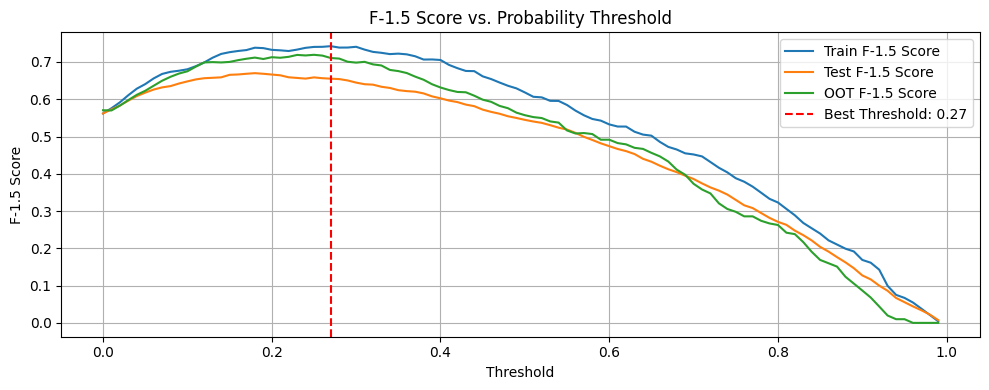

In [98]:
# F2 score across thresholds
thresholds = np.arange(0.0, 1.0, 0.01)
beta = 1.5
f1_scores_train = [fbeta_score(y_train_arr, y_pred_proba_train > t, beta=beta) for t in thresholds]
f1_scores_test = [fbeta_score(y_test_arr, y_pred_proba_test > t, beta=beta) for t in thresholds]
f1_scores_oot = [fbeta_score(y_oot_arr, y_pred_proba_oot > t, beta=beta) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores_train)]

# Plot F1 Score vs. Threshold
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores_train, label=f"Train F-{beta} Score")
plt.plot(thresholds, f1_scores_test, label=f"Test F-{beta} Score")
plt.plot(thresholds, f1_scores_oot, label=f"OOT F-{beta} Score")
plt.axvline(x=best_threshold, color="red", linestyle="--", label=f"Best Threshold: {best_threshold:.2f}")
plt.title(f"F-{beta} Score vs. Probability Threshold")
plt.xlabel("Threshold")
plt.ylabel(f"F-{beta} Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

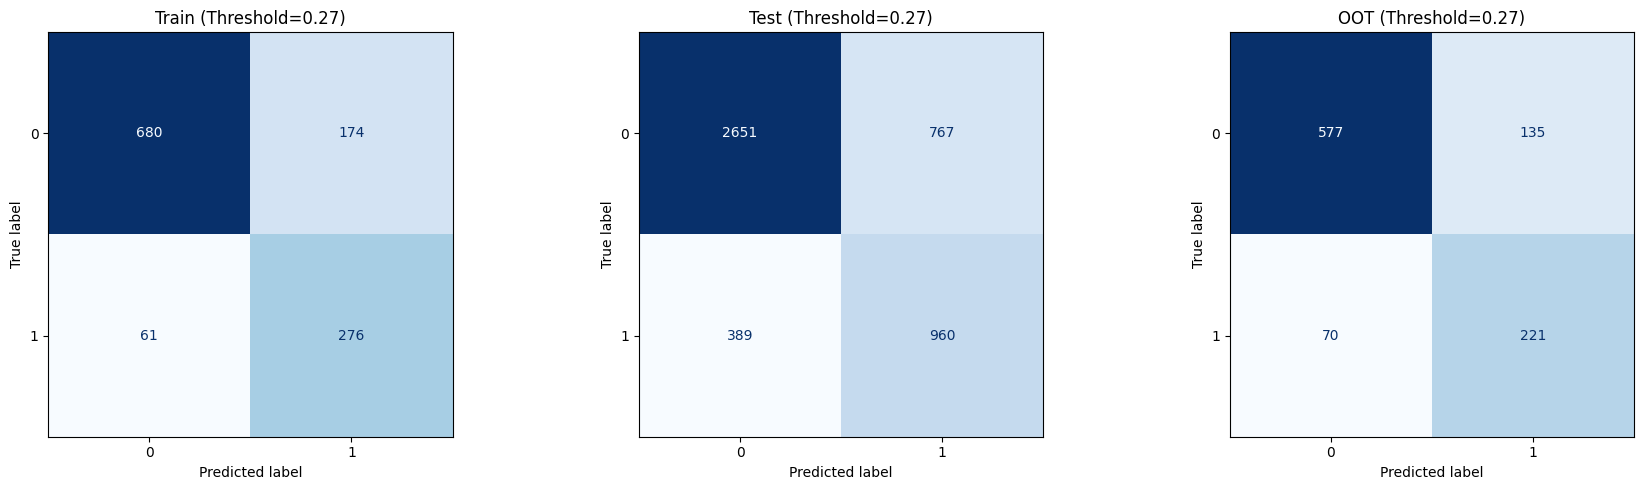

In [99]:
# Predictions
y_pred_train = (y_pred_proba_train > best_threshold).astype(int)
y_pred_test = (y_pred_proba_test > best_threshold).astype(int)
y_pred_oot = (y_pred_proba_oot > best_threshold).astype(int)

# Confusion matrices
cm_train = confusion_matrix(y_train_arr, y_pred_train)
cm_test = confusion_matrix(y_test_arr, y_pred_test)
cm_oot = confusion_matrix(y_oot_arr, y_pred_oot)

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Train
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(ax=axs[0], cmap='Blues', colorbar=False)
axs[0].set_title(f"Train (Threshold={best_threshold:.2f})")
axs[0].grid(False)

# Test
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(ax=axs[1], cmap='Blues', colorbar=False)
axs[1].set_title(f"Test (Threshold={best_threshold:.2f})")
axs[1].grid(False)

# OOT
disp_oot = ConfusionMatrixDisplay(confusion_matrix=cm_oot)
disp_oot.plot(ax=axs[2], cmap='Blues', colorbar=False)
axs[2].set_title(f"OOT (Threshold={best_threshold:.2f})")
axs[2].grid(False)

plt.tight_layout()
plt.show()

In [100]:
print(f"Best Train F{beta}-Score: {max(f1_scores_train):.4f}")
print(f"Best Test F{beta}-Score: {max(f1_scores_test):.4f}")
print(f"Best OOT F{beta}-Score: {max(f1_scores_oot):.4f}")

Best Train F1.5-Score: 0.7424
Best Test F1.5-Score: 0.6700
Best OOT F1.5-Score: 0.7192


## b. XGBoost

In [101]:
# Define the XGBoost classifier
xgb_clf = xgb.XGBClassifier(eval_metric='logloss', random_state=88)

# Define the hyperparameter space to search
param_dist = {
    'n_estimators': [25, 50],
    'max_depth': [2, 3],  # lower max_depth to simplify the model
    'learning_rate': [0.01, 0.1],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8],
    'gamma': [0, 0.1],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

# Create a scorer based on AUC score
auc_scorer = make_scorer(roc_auc_score)

# Set up the random search with cross-validation
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    scoring=auc_scorer,
    n_iter=100,  # Number of iterations for random search
    cv=3,       # Number of folds in cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Perform the random search
random_search.fit(X_train_arr, y_train_arr)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           num_parallel_tree=None, ...),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8],
                                        'gamma': [0, 0.1],
                                        'learning_rate': [0.01, 0.1],
                                        'max_depth': [2, 3],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [25, 50],
                                        'reg_alpha': [0, 0.1, 1],
                                        'reg_lambda': [1, 1.5, 2],
                                        'subsample': [0.6, 0.8]},
                   random_state=42,
                   scoring=make_scorer(roc_auc_score, response_method='predict'),
                   verbose=1)

In [102]:
# Output the best parameters and best score
print("Best parameters found: ", random_search.best_params_)
print("Best AUC score: ", random_search.best_score_)

# Evaluate the model on the train set
best_model = random_search.best_estimator_
y_pred_proba = best_model.predict_proba(X_train_arr)[:, 1]
train_auc_score = roc_auc_score(y_train_arr, y_pred_proba)
print("Train AUC score: ", train_auc_score)

# Evaluate the model on the test set
best_model = random_search.best_estimator_
y_pred_proba = best_model.predict_proba(X_test_arr)[:, 1]
test_auc_score = roc_auc_score(y_test_arr, y_pred_proba)
print("Test AUC score: ", test_auc_score)

# Evaluate the model on the oot set
best_model = random_search.best_estimator_
y_pred_proba = best_model.predict_proba(X_oot_arr)[:, 1]
oot_auc_score = roc_auc_score(y_oot_arr, y_pred_proba)
print("OOT AUC score: ", oot_auc_score)

print("TRAIN GINI score: ", round(2*train_auc_score-1,3))
print("Test GINI score: ", round(2*test_auc_score-1,3))
print("OOT GINI score: ", round(2*oot_auc_score-1,3))

Best parameters found:  {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 50, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best AUC score:  0.7445139852727086
Train AUC score:  0.9553645265081758
Test AUC score:  0.8389338525687711
OOT AUC score:  0.879739565234179
TRAIN GINI score:  0.911
Test GINI score:  0.678
OOT GINI score:  0.759


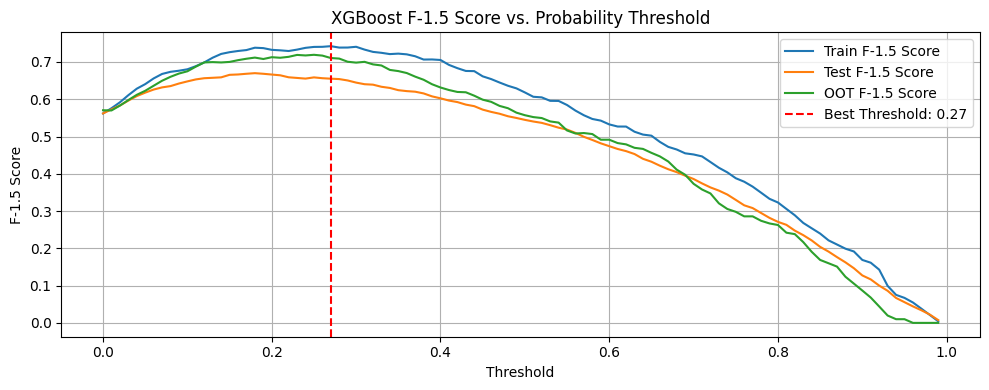

Best threshold (Train F-1.5 max): 0.27


In [103]:
# F2 score across thresholds
thresholds = np.arange(0.0, 1.0, 0.01)
beta = 1.5
f2_scores_train = [fbeta_score(y_train_arr, y_pred_proba_train > t, beta=beta) for t in thresholds]
f2_scores_test = [fbeta_score(y_test_arr, y_pred_proba_test > t, beta=beta) for t in thresholds]
f2_scores_oot = [fbeta_score(y_oot_arr, y_pred_proba_oot > t, beta=beta) for t in thresholds]

#Find the best trshhold on F2
best_threshold = thresholds[np.argmax(f2_scores_train)]

# Plotting F1.5 vs Threshold
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f2_scores_train, label=f"Train F-{beta} Score")
plt.plot(thresholds, f2_scores_test, label=f"Test F-{beta} Score")
plt.plot(thresholds, f2_scores_oot, label=f"OOT F-{beta} Score")
plt.axvline(x=best_threshold, color="red", linestyle="--", label=f"Best Threshold: {best_threshold:.2f}")
plt.title(f"XGBoost F-{beta} Score vs. Probability Threshold")
plt.xlabel("Threshold")
plt.ylabel(f"F-{beta} Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print Best Threshold
print(f"Best threshold (Train F-{beta} max): {best_threshold:.2f}")


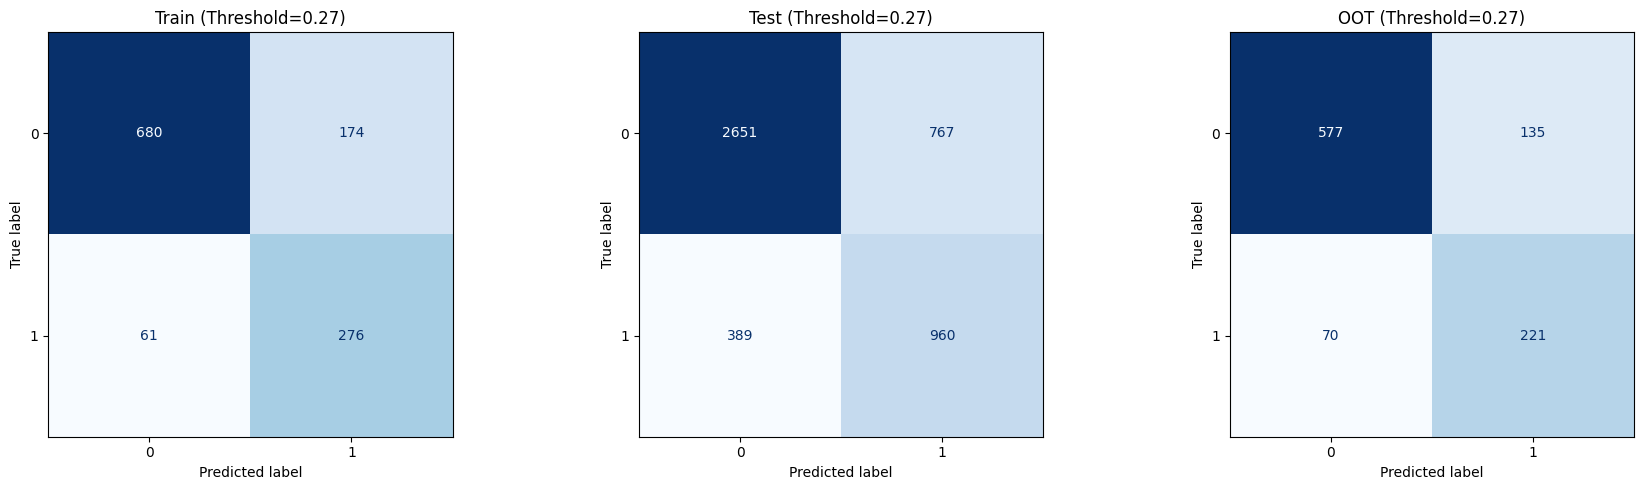

In [104]:
# Predictions
y_pred_train = (y_pred_proba_train > best_threshold).astype(int)
y_pred_test = (y_pred_proba_test > best_threshold).astype(int)
y_pred_oot = (y_pred_proba_oot > best_threshold).astype(int)

# Confusion matrices
cm_train = confusion_matrix(y_train_arr, y_pred_train)
cm_test = confusion_matrix(y_test_arr, y_pred_test)
cm_oot = confusion_matrix(y_oot_arr, y_pred_oot)

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Train
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(ax=axs[0], cmap='Blues', colorbar=False)
axs[0].set_title(f"Train (Threshold={best_threshold:.2f})")
axs[0].grid(False)

# Test
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(ax=axs[1], cmap='Blues', colorbar=False)
axs[1].set_title(f"Test (Threshold={best_threshold:.2f})")
axs[1].grid(False)

# OOT
disp_oot = ConfusionMatrixDisplay(confusion_matrix=cm_oot)
disp_oot.plot(ax=axs[2], cmap='Blues', colorbar=False)
axs[2].set_title(f"OOT (Threshold={best_threshold:.2f})")
axs[2].grid(False)

plt.tight_layout()
plt.show()

In [105]:
# default 0.5
print("\n👉 Default threshold 0.5 results:")
precision_05_train = precision_score(y_train_arr, y_pred_proba_train > 0.5)
recall_05_train = recall_score(y_train_arr, y_pred_proba_train > 0.5)
f2_05_train = fbeta_score(y_train_arr, y_pred_proba_train > 0.5, beta=1.5)

precision_05_test = precision_score(y_test_arr, y_pred_proba_test > 0.5)
recall_05_test = recall_score(y_test_arr, y_pred_proba_test > 0.5)
f2_05_test = fbeta_score(y_test_arr, y_pred_proba_test > 0.5, beta=1.5)

precision_05_oot = precision_score(y_oot_arr, y_pred_proba_oot > 0.5)
recall_05_oot = recall_score(y_oot_arr, y_pred_proba_oot > 0.5)
f2_05_oot = fbeta_score(y_oot_arr, y_pred_proba_oot > 0.5, beta=1.5)

print(f"Train: Precision={precision_05_train:.3f}, Recall={recall_05_train:.3f}, F1.5={f2_05_train:.3f}")
print(f"Test: Precision={precision_05_test:.3f}, Recall={recall_05_test:.3f}, F1.5={f2_05_test:.3f}")
print(f"OOT: Precision={precision_05_oot:.3f}, Recall={recall_05_oot:.3f}, F1.5={f2_05_oot:.3f}")

# best threshold from your F2 analysis (0.27)
print("\n👉 Best threshold 0.27 results:")
precision_best_train = precision_score(y_train_arr, y_pred_proba_train > 0.27)
recall_best_train = recall_score(y_train_arr, y_pred_proba_train > 0.27)
f2_best_train = fbeta_score(y_train_arr, y_pred_proba_train > 0.27, beta=1.5)

precision_best_test = precision_score(y_test_arr, y_pred_proba_test > 0.27)
recall_best_test = recall_score(y_test_arr, y_pred_proba_test > 0.27)
f2_best_test = fbeta_score(y_test_arr, y_pred_proba_test > 0.27, beta=1.5)

precision_best_oot = precision_score(y_oot_arr, y_pred_proba_oot > 0.27)
recall_best_oot = recall_score(y_oot_arr, y_pred_proba_oot > 0.27)
f2_best_oot = fbeta_score(y_oot_arr, y_pred_proba_oot > 0.27, beta=1.5)

print(f"Train: Precision={precision_best_train:.3f}, Recall={recall_best_train:.3f}, F1.5={f2_best_train:.3f}")
print(f"Test: Precision={precision_best_test:.3f}, Recall={recall_best_test:.3f}, F1.5={f2_best_test:.3f}")
print(f"OOT: Precision={precision_best_oot:.3f}, Recall={recall_best_oot:.3f}, F1.5={f2_best_oot:.3f}")



👉 Default threshold 0.5 results:
Train: Precision=0.721, Recall=0.582, F1.5=0.618
Test: Precision=0.674, Recall=0.502, F1.5=0.545
OOT: Precision=0.759, Recall=0.498, F1.5=0.557

👉 Best threshold 0.27 results:
Train: Precision=0.613, Recall=0.819, F1.5=0.742
Test: Precision=0.556, Recall=0.712, F1.5=0.655
OOT: Precision=0.621, Recall=0.759, F1.5=0.711


I evaluate the improvement not just by looking at precision and recall individually, but by observing whether the overall F1.5 score increases after adjusting the threshold. Additionally, I check if this improvement is consistent across the test and OOT datasets to ensure the model is not overfitting. Finally, I assess whether the precision-recall balance aligns with the business objective, prioritizing higher recall and higher precision as required.

## Model Comparison and Selection

**For Logistic Regrassion:**

Train AUC: 0.8759

Test AUC: 0.8071

OOT AUC: 0.8536


Test AUC value > 0.8, indicating that the model has good generalization ability on unseen data.

The Train AUC is 0.06 higher than Test AUC, which suggest the model is slight overfitting, but still acceptable.

OOT AUC is even higher than Test AUC, indicating that the model is stale on OOT data.

**For XGBoost:**

Train AUC score:  0.9553645265081758

Test AUC score:  0.8389338525687711

OOT AUC score:  0.879739565234179

Test AUC value > 0.8, which means the model has good generalization ability on unseen data.

However, the Train AUC is 0.12 higher than Test AUC, which indicates that the model is noticeable overfitting.

OOT AUC is even higher than Test AUC, showing that the model performs well on OOT data.

**Compared to Logistic Regression, XGBoost has higher test AUC and OOT AUC, suggesting it has higher generalization ability and stability. Althogh logistic provides good interpretability, I choose XGBoost for its excellent predictive performance.**

## Prepare model artefact to save

In [106]:
model_artefact = {}

model_artefact['model'] = best_model
model_artefact['model_version'] = "credit_model_"+config["model_train_date_str"].replace('-','_')
model_artefact['preprocessing_transformers'] = {}
model_artefact['preprocessing_transformers']['stdscaler'] = transformer_stdscaler
model_artefact['data_dates'] = config
model_artefact['data_stats'] = {}
model_artefact['data_stats']['X_train_arr'] = X_train_arr.shape[0]
model_artefact['data_stats']['X_test_arr'] = X_test_arr.shape[0]
model_artefact['data_stats']['X_oot_arr'] = X_oot_arr.shape[0]
model_artefact['data_stats']['y_train_arr'] = round(y_train_arr.mean(),2)
model_artefact['data_stats']['y_test_arr'] = round(y_test_arr.mean(),2)
model_artefact['data_stats']['y_oot_arr'] = round(y_oot_arr.mean(),2)
model_artefact['results'] = {}
model_artefact['results']['auc_train'] = train_auc_score
model_artefact['results']['auc_test'] = test_auc_score
model_artefact['results']['auc_oot'] = oot_auc_score
model_artefact['results']['gini_train'] = round(2*train_auc_score-1,3)
model_artefact['results']['gini_test'] = round(2*test_auc_score-1,3)
model_artefact['results']['gini_oot'] = round(2*oot_auc_score-1,3)
model_artefact['hp_params'] = random_search.best_params_
model_artefact["feature_columns"] = X_train.drop(columns=['customer_id','snapshot_date']).columns.tolist()


pprint.pprint(model_artefact)

{'data_dates': {'model_train_date': datetime.datetime(2024, 9, 1, 0, 0),
                'model_train_date_str': '2024-09-01',
                'oot_end_date': datetime.datetime(2024, 8, 31, 0, 0),
                'oot_period_months': 2,
                'oot_start_date': datetime.datetime(2024, 7, 1, 0, 0),
                'train_test_end_date': datetime.datetime(2024, 6, 30, 0, 0),
                'train_test_period_months': 12,
                'train_test_ratio': 0.8,
                'train_test_start_date': datetime.datetime(2023, 7, 1, 0, 0)},
 'data_stats': {'X_oot_arr': 1003,
                'X_test_arr': 4767,
                'X_train_arr': 1191,
                'y_oot_arr': np.float64(0.29),
                'y_test_arr': np.float64(0.28),
                'y_train_arr': np.float64(0.28)},
 'feature_columns': ['age',
                     'annual_income',
                     'monthly_inhand_salary',
                     'num_bank_accounts',
                     'num_credit_card',


## save artefact to model bank

In [107]:
# create model_bank dir
model_bank_directory = "model_bank/"

if not os.path.exists(model_bank_directory):
    os.makedirs(model_bank_directory)

In [108]:
# Full path to the file
file_path = os.path.join(model_bank_directory, model_artefact['model_version'] + '.pkl')

# Write the model to a pickle file
with open(file_path, 'wb') as file:
    pickle.dump(model_artefact, file)

print(f"Model saved to {file_path}")

Model saved to model_bank/credit_model_2024_09_01.pkl


## test load pickle and make model inference

In [109]:
# Load the model from the pickle file
with open(file_path, 'rb') as file:
    loaded_model_artefact = pickle.load(file)

y_pred_proba = loaded_model_artefact['model'].predict_proba(X_oot_arr)[:, 1]
oot_auc_score = roc_auc_score(y_oot_arr, y_pred_proba)
print("OOT AUC score: ", oot_auc_score)

print("Model loaded successfully!")

OOT AUC score:  0.879739565234179
Model loaded successfully!
